### Dataset Heirarchy Test

In [1]:
# import os
# import pandas as pd

# DATADIR = '/home/bodhdipta/Downloads/DeepFish'

# print("Testing DeepFish Dataset Structure\n")
# print("="*80)

# # Test Classification
# print("\n1. CLASSIFICATION DATASET:")
# print("-"*80)
# csv_path = os.path.join(DATADIR, 'Classification', 'train.csv')
# df = pd.read_csv(csv_path)
# print(f"CSV columns: {df.columns.tolist()}")
# print(f"Number of samples: {len(df)}")
# print(f"\nFirst 5 IDs:")
# print(df['ID'].head())
# print(f"\nLabel distribution:")
# print(df['labels'].value_counts())

# images_dir = os.path.join(DATADIR, 'Classification', 'images')
# print(f"\nDirectory structure:")
# for root, dirs, files in os.walk(images_dir):
#     level = root.replace(images_dir, '').count(os.sep)
#     if level < 3:
#         indent = '  ' * level
#         print(f'{indent}{os.path.basename(root)}/')
#         if level == 2:
#             print(f'{indent}  ({len(files)} images)')

# # Test Localization
# print("\n\n2. LOCALIZATION DATASET:")
# print("-"*80)
# csv_path = os.path.join(DATADIR, 'Localization', 'train.csv')
# if os.path.exists(csv_path):
#     df = pd.read_csv(csv_path)
#     print(f"CSV columns: {df.columns.tolist()}")
#     print(f"Number of samples: {len(df)}")
#     print(f"\nFirst 5 IDs:")
#     print(df['ID'].head())
# else:
#     print("Localization CSV not found")

# # Test Segmentation
# print("\n\n3. SEGMENTATION DATASET:")
# print("-"*80)
# csv_path = os.path.join(DATADIR, 'Segmentation', 'train.csv')
# if os.path.exists(csv_path):
#     df = pd.read_csv(csv_path)
#     print(f"CSV columns: {df.columns.tolist()}")
#     print(f"Number of samples: {len(df)}")
#     print(f"\nFirst 5 IDs:")
#     print(df['ID'].head())
# else:
#     print("Segmentation CSV not found")

# print("\n" + "="*80)


# DeepFish Dataset: Fish Detection, Classification, and Localization

This notebook provides a complete implementation for training models on the DeepFish dataset for three tasks:
1. **Classification**: Binary classification (fish present/absent)
2. **Localization**: Fish counting using point annotations
3. **Segmentation**: Pixel-wise fish segmentation

## Dataset Structure
- Classification: `images/{habitat}/{valid|empty}/{image}.jpg`
- Localization: `images/{image}.jpg` + `masks/{image}.png`
- Segmentation: `images/{image}.jpg` + `masks/{image}.png`


In [2]:
# %pip install torch torchvision torchaudio numpy pandas pillow opencv-python tqdm matplotlib scikit-learn jupyter

#### Importing Libraries

In [3]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.8.0+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4060 Laptop GPU


#### Configuration

In [4]:
# Configuration
DATADIR = '/home/bodhdipta/Downloads/DeepFish'  # Update this path
BATCH_SIZE_CLF = 32
BATCH_SIZE_LOC = 2
BATCH_SIZE_SEG = 2
NUM_WORKERS = 1
EPOCHS = 50
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Using device: {DEVICE}")
print(f"Dataset directory: {DATADIR}")

Using device: cuda
Dataset directory: /home/bodhdipta/Downloads/DeepFish


## Dataset Classes

Custom PyTorch Dataset classes for each task


In [5]:
class DeepFishClassification(Dataset):
    """
    Classification dataset - images are directly in Classification/{habitat}/{valid|empty}/
    Structure: Classification/{habitat_code}/{valid|empty}/{image}.jpg
    """
    def __init__(self, datadir, split='train', transform=None):
        self.datadir = datadir
        self.split = split
        self.transform = transform
        
        # Load CSV file
        csv_path = os.path.join(datadir, 'Classification', f'{split}.csv')
        self.df = pd.read_csv(csv_path)
        
        # Images are directly in Classification folder, NOT in images subfolder!
        self.images_base_dir = os.path.join(datadir, 'Classification')
        
        print(f"Loaded {len(self.df)} images for {self.split} split")
        print(f"Images base directory: {self.images_base_dir}")
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # Get image ID and label
        img_id = str(self.df.iloc[idx]['ID'])
        label = int(self.df.iloc[idx]['labels'])
        
        # CSV ID format: "7463/empty/7463_NF3_f000092"
        # Construct full path: {base_dir}/7463/empty/7463_NF3_f000092.jpg
        img_path = os.path.join(self.images_base_dir, img_id)
        
        # Add .jpg extension if not present
        if not img_path.endswith(('.jpg', '.png', '.jpeg')):
            img_path += '.jpg'
        
        # Verify file exists
        if not os.path.exists(img_path):
            raise FileNotFoundError(
                f"Image not found: {img_id}\n"
                f"  Full path: {img_path}\n"
                f"  Base dir: {self.images_base_dir}"
            )
        
        # Load image
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

print("✓ Classification Dataset class defined (FIXED - no images/ subfolder)")


✓ Classification Dataset class defined (FIXED - no images/ subfolder)


In [6]:
class DeepFishLocalization(Dataset):
    """
    Localization dataset with point annotations for counting
    Structure: Localization/images/{image}.jpg and Localization/masks/{image}.png
    """
    def __init__(self, datadir, split='train', transform=None):
        self.datadir = datadir
        self.split = split
        self.transform = transform
        
        # Load CSV file
        csv_path = os.path.join(datadir, 'Localization', f'{split}.csv')
        self.df = pd.read_csv(csv_path)
        
        self.images_dir = os.path.join(datadir, 'Localization', 'images')
        self.masks_dir = os.path.join(datadir, 'Localization', 'masks')
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # Get image ID, label, and count
        img_id = str(self.df.iloc[idx]['ID'])
        label = int(self.df.iloc[idx]['labels'])
        count = int(self.df.iloc[idx]['counts'])
        
        # Remove extension if present
        img_id_base = img_id.replace('.jpg', '').replace('.png', '')
        
        # Load image
        img_path = os.path.join(self.images_dir, f'{img_id_base}.jpg')
        image = Image.open(img_path).convert('RGB')
        
        # Load point annotation mask
        mask_path = os.path.join(self.masks_dir, f'{img_id_base}.png')
        mask = Image.open(mask_path)
        mask = np.array(mask)
        
        if self.transform:
            image = self.transform(image)
            mask = torch.from_numpy(mask).float() / 255.0
            
        return {
            'image': image,
            'mask': mask,
            'count': count,
            'label': label,
            'id': img_id
        }

print("✓ Localization Dataset class defined")


✓ Localization Dataset class defined


In [7]:
class DeepFishSegmentation(Dataset):
    """
    Segmentation dataset with pixel-level masks
    Structure: Segmentation/images/{image}.jpg and Segmentation/masks/{image}.png
    """
    def __init__(self, datadir, split='train', transform=None):
        self.datadir = datadir
        self.split = split
        self.transform = transform
        
        # Load CSV file
        csv_path = os.path.join(datadir, 'Segmentation', f'{split}.csv')
        self.df = pd.read_csv(csv_path)
        
        self.images_dir = os.path.join(datadir, 'Segmentation', 'images')
        self.masks_dir = os.path.join(datadir, 'Segmentation', 'masks')
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # Get image ID and label
        img_id = str(self.df.iloc[idx]['ID'])
        label = int(self.df.iloc[idx]['labels'])
        
        # Remove extension if present
        img_id_base = img_id.replace('.jpg', '').replace('.png', '')
        
        # Load image
        img_path = os.path.join(self.images_dir, f'{img_id_base}.jpg')
        image = Image.open(img_path).convert('RGB')
        
        # Load segmentation mask (0-255 range)
        mask_path = os.path.join(self.masks_dir, f'{img_id_base}.png')
        mask = Image.open(mask_path)
        mask = np.array(mask)
        
        # Convert mask to 0-1 range (binary segmentation)
        mask = (mask > 0).astype(np.float32)
        
        if self.transform:
            image = self.transform(image)
            mask = torch.from_numpy(mask).float()
            
        return {
            'image': image,
            'mask': mask,
            'label': label,
            'id': img_id
        }

print("✓ Segmentation Dataset class defined")


✓ Segmentation Dataset class defined


## Model Architectures

Neural network models for each task

In [8]:
class FishClassifier(nn.Module):
    """Classification model for fish presence/absence"""
    def __init__(self, num_classes=2, backbone='resnet18'):
        super(FishClassifier, self).__init__()
        
        # Initialize backbone based on choice
        if backbone == 'resnet18':
            self.backbone = models.resnet18(pretrained=True)
            num_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Linear(num_features, num_classes)
        elif backbone == 'resnet34':
            self.backbone = models.resnet34(pretrained=True)
            num_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Linear(num_features, num_classes)
        elif backbone == 'resnet50':
            self.backbone = models.resnet50(pretrained=True)
            num_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Linear(num_features, num_classes)
        else:
            raise ValueError(f"Unsupported backbone: {backbone}")
        
    def forward(self, x):
        return self.backbone(x)

print("✓ Classification Model defined")

# Test model creation
test_model = FishClassifier(num_classes=2, backbone='resnet18')
print(f"✓ Model has {sum(p.numel() for p in test_model.parameters())} parameters")
del test_model

✓ Classification Model defined
✓ Model has 11177538 parameters


In [9]:
class FishLocalizer(nn.Module):
    """Localization model for fish counting"""
    def __init__(self):
        super(FishLocalizer, self).__init__()
        # Use FCN for density map prediction
        self.backbone = models.segmentation.fcn_resnet50(pretrained=True)
        # Modify for single channel output (density map)
        self.backbone.classifier[4] = nn.Conv2d(512, 1, kernel_size=1)
        
    def forward(self, x):
        return self.backbone(x)['out']

print("✓ Localization Model defined")

✓ Localization Model defined


In [10]:
class FishSegmenter(nn.Module):
    """Segmentation model for pixel-wise fish detection"""
    def __init__(self):
        super(FishSegmenter, self).__init__()
        self.backbone = models.segmentation.fcn_resnet50(pretrained=True)
        # Modify for binary segmentation
        self.backbone.classifier[4] = nn.Conv2d(512, 1, kernel_size=1)
        
    def forward(self, x):
        return self.backbone(x)['out']

print("✓ Segmentation Model defined")

✓ Segmentation Model defined


## Training Functions

Training loops for each task


In [11]:
def train_classification(model, train_loader, val_loader, epochs=50, 
                        save_path='fish_classifier.pth', device='cuda'):
    """Train classification model"""
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                      patience=5, factor=0.5)
    
    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
            pbar.set_postfix({'loss': loss.item(), 
                            'acc': 100 * train_correct / train_total})
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]'):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        
        # Save history
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        
        print(f'\nEpoch {epoch+1}/{epochs}:')
        print(f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        print(f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%')
        
        scheduler.step(avg_val_loss)
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
            print(f'✓ Model saved with validation accuracy: {val_acc:.2f}%')
    
    print(f'\n🎯 Best validation accuracy: {best_val_acc:.2f}%')
    return history

print("✓ Classification training function defined")

✓ Classification training function defined


In [12]:
def train_localization(model, train_loader, val_loader, epochs=50, 
                      save_path='fish_localizer.pth', device='cuda'):
    """Train localization model"""
    model = model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                      patience=5, factor=0.5)
    
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]')
        for batch in pbar:
            images = batch['image'].to(device)
            masks = batch['mask'].to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            
            # Resize outputs to match mask size if needed
            if outputs.shape[-2:] != masks.shape[-2:]:
                outputs = torch.nn.functional.interpolate(
                    outputs, size=masks.shape[-2:], mode='bilinear', align_corners=False
                )
            
            # Expand mask dimensions if needed
            if len(masks.shape) == 3:
                masks = masks.unsqueeze(1)
            
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]'):
                images = batch['image'].to(device)
                masks = batch['mask'].to(device)
                
                outputs = model(images)
                
                if outputs.shape[-2:] != masks.shape[-2:]:
                    outputs = torch.nn.functional.interpolate(
                        outputs, size=masks.shape[-2:], mode='bilinear', align_corners=False
                    )
                
                if len(masks.shape) == 3:
                    masks = masks.unsqueeze(1)
                
                loss = criterion(outputs, masks)
                val_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        
        # Save history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        
        print(f'\nEpoch {epoch+1}/{epochs}:')
        print(f'Train Loss: {avg_train_loss:.4f}')
        print(f'Val Loss: {avg_val_loss:.4f}')
        
        scheduler.step(avg_val_loss)
        
        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)
            print(f'✓ Model saved with validation loss: {avg_val_loss:.4f}')
    
    print(f'\n🎯 Best validation loss: {best_val_loss:.4f}')
    return history

print("✓ Localization training function defined")

✓ Localization training function defined


In [13]:
def train_segmentation(model, train_loader, val_loader, epochs=50, 
                      save_path='fish_segmenter.pth', device='cuda'):
    """Train segmentation model"""
    model = model.to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                      patience=5, factor=0.5)
    
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]')
        for batch in pbar:
            images = batch['image'].to(device)
            masks = batch['mask'].to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            
            # Resize outputs to match mask size if needed
            if outputs.shape[-2:] != masks.shape[-2:]:
                outputs = torch.nn.functional.interpolate(
                    outputs, size=masks.shape[-2:], mode='bilinear', align_corners=False
                )
            
            loss = criterion(outputs.squeeze(1), masks)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]'):
                images = batch['image'].to(device)
                masks = batch['mask'].to(device)
                
                outputs = model(images)
                
                if outputs.shape[-2:] != masks.shape[-2:]:
                    outputs = torch.nn.functional.interpolate(
                        outputs, size=masks.shape[-2:], mode='bilinear', align_corners=False
                    )
                
                loss = criterion(outputs.squeeze(1), masks)
                val_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        
        # Save history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        
        print(f'\nEpoch {epoch+1}/{epochs}:')
        print(f'Train Loss: {avg_train_loss:.4f}')
        print(f'Val Loss: {avg_val_loss:.4f}')
        
        scheduler.step(avg_val_loss)
        
        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)
            print(f'✓ Model saved with validation loss: {avg_val_loss:.4f}')
    
    print(f'\n🎯 Best validation loss: {best_val_loss:.4f}')
    return history

print("✓ Segmentation training function defined")

✓ Segmentation training function defined


## Data Preparation

Define transforms and create datasets


In [14]:
# Data transforms
train_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                       std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                       std=[0.229, 0.224, 0.225])
])

print("✓ Transforms defined")


✓ Transforms defined


# Task 1: Fish Classification

Binary classification to detect fish presence/absence


In [15]:
# Initialize Classification datasets
print("Initializing Classification datasets...")
train_clf = DeepFishClassification(DATADIR, split='train', transform=train_transform)
val_clf = DeepFishClassification(DATADIR, split='val', transform=val_transform)

print(f"\nDataset sizes:")
print(f"Training: {len(train_clf)} images")
print(f"Validation: {len(val_clf)} images")

Initializing Classification datasets...
Loaded 15906 images for train split
Images base directory: /home/bodhdipta/Downloads/DeepFish/Classification
Loaded 3976 images for val split
Images base directory: /home/bodhdipta/Downloads/DeepFish/Classification

Dataset sizes:
Training: 15906 images
Validation: 3976 images


In [16]:
# Create Classification DataLoaders
train_loader_clf = DataLoader(
    train_clf, 
    batch_size=BATCH_SIZE_CLF, 
    shuffle=True, 
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader_clf = DataLoader(
    val_clf, 
    batch_size=BATCH_SIZE_CLF, 
    shuffle=False, 
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("✓ Classification DataLoaders created")
print(f"  Train batches: {len(train_loader_clf)}")
print(f"  Val batches: {len(val_loader_clf)}")

✓ Classification DataLoaders created
  Train batches: 498
  Val batches: 125


In [17]:
# Test Classification dataset
print("Testing Classification dataset...")
sample_image, sample_label = train_clf[0]
print(f"Image shape: {sample_image.shape}")
print(f"Label: {sample_label}")

# Test a batch
for images, labels in train_loader_clf:
    print(f"\nBatch shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
    print(f"Labels: {labels[:5]}")  # First 5 labels
    break

print("\n✓ Classification dataset working correctly!")

Testing Classification dataset...
Image shape: torch.Size([3, 512, 512])
Label: 0

Batch shape: torch.Size([32, 3, 512, 512])
Labels shape: torch.Size([32])
Labels: tensor([0, 0, 0, 0, 0])

✓ Classification dataset working correctly!


In [18]:
print("\n" + "="*80)
print("TRAINING CLASSIFICATION MODEL")
print("="*80)

# Clear memory first
import gc
gc.collect()
torch.cuda.empty_cache()

# Create model with ResNet18 (lighter and fits in memory)
print("Creating model...")
clf_model = FishClassifier(num_classes=2, backbone='resnet18')  # Use resnet18!

# Verify model has parameters
num_params = sum(p.numel() for p in clf_model.parameters())
print(f"✓ Model created with {num_params:,} parameters")

if num_params == 0:
    raise ValueError("Model has no parameters! Check model initialization.")

# Check memory
if torch.cuda.is_available():
    print(f"GPU Memory before training: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")

# Train
clf_history = train_classification(
    clf_model, 
    train_loader_clf, 
    val_loader_clf, 
    epochs=EPOCHS,
    save_path='fish_classifier.pth',
    device=DEVICE
)


TRAINING CLASSIFICATION MODEL
Creating model...
✓ Model created with 11,177,538 parameters
GPU Memory before training: 0.00 GB


Epoch 1/50 [Val]: 100%|██████████| 125/125 [00:46<00:00,  2.67it/s]



Epoch 1/50:
Train Loss: 0.4746, Train Acc: 77.42%
Val Loss: 0.2866, Val Acc: 87.30%
✓ Model saved with validation accuracy: 87.30%


Epoch 2/50 [Val]: 100%|██████████| 125/125 [00:45<00:00,  2.78it/s]



Epoch 2/50:
Train Loss: 0.3099, Train Acc: 87.62%
Val Loss: 0.1533, Val Acc: 94.77%
✓ Model saved with validation accuracy: 94.77%


...


Epoch 48/50:
Train Loss: 0.0104, Train Acc: 99.69%
Val Loss: 0.0184, Val Acc: 99.60%


Epoch 49/50 [Val]: 100%|██████████| 125/125 [00:46<00:00,  2.71it/s]



Epoch 49/50:
Train Loss: 0.0070, Train Acc: 99.89%
Val Loss: 0.0187, Val Acc: 99.57%


Epoch 50/50 [Val]: 100%|██████████| 125/125 [00:45<00:00,  2.78it/s]


Epoch 50/50:
Train Loss: 0.0068, Train Acc: 99.83%
Val Loss: 0.0119, Val Acc: 99.72%
✓ Model saved with validation accuracy: 99.72%

🎯 Best validation accuracy: 99.72%


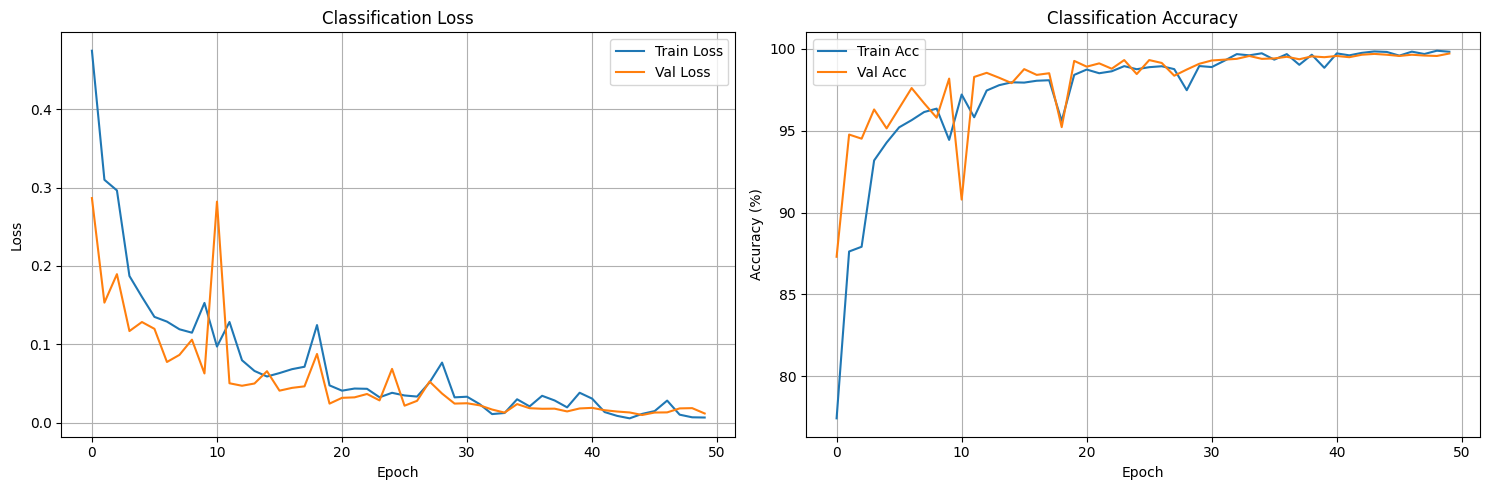

In [19]:
import matplotlib.pyplot as plt

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(clf_history['train_loss'], label='Train Loss')
axes[0].plot(clf_history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Classification Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(clf_history['train_acc'], label='Train Acc')
axes[1].plot(clf_history['val_acc'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Classification Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Task 2: Fish Localization & Counting

Point-level annotations for fish counting


In [20]:
# Initialize Localization datasets
print("Initializing Localization datasets...")
train_loc = DeepFishLocalization(DATADIR, split='train', transform=train_transform)
val_loc = DeepFishLocalization(DATADIR, split='val', transform=val_transform)

print(f"\nDataset sizes:")
print(f"Training: {len(train_loc)} images")
print(f"Validation: {len(val_loc)} images")

Initializing Localization datasets...

Dataset sizes:
Training: 1600 images
Validation: 640 images


In [21]:
# Create Localization DataLoaders
train_loader_loc = DataLoader(
    train_loc, 
    batch_size=BATCH_SIZE_LOC, 
    shuffle=True, 
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader_loc = DataLoader(
    val_loc, 
    batch_size=BATCH_SIZE_LOC, 
    shuffle=False, 
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("✓ Localization DataLoaders created")
print(f"  Train batches: {len(train_loader_loc)}")
print(f"  Val batches: {len(val_loader_loc)}")

✓ Localization DataLoaders created
  Train batches: 800
  Val batches: 320


In [22]:
# Test Localization dataset
print("Testing Localization dataset...")
sample_batch = next(iter(train_loader_loc))
print(f"Image shape: {sample_batch['image'].shape}")
print(f"Mask shape: {sample_batch['mask'].shape}")
print(f"Count: {sample_batch['count'][:5]}")  # First 5 counts

print("\n✓ Localization dataset working correctly!")

Testing Localization dataset...
Image shape: torch.Size([2, 3, 512, 512])
Mask shape: torch.Size([2, 1080, 1920])
Count: tensor([6, 2])

✓ Localization dataset working correctly!


In [ ]:
# Initialize and train Localization model
print("\n" + "="*80)
print("TRAINING LOCALIZATION MODEL")
print("="*80)

loc_model = FishLocalizer()
loc_history = train_localization(
    loc_model, 
    train_loader_loc, 
    val_loader_loc, 
    epochs=EPOCHS,
    save_path='fish_localizer.pth',
    device=DEVICE
)

In [ ]:
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(loc_history['train_loss'], label='Train Loss')
plt.plot(loc_history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Localization Loss')
plt.legend()
plt.grid(True)
plt.show()


# Task 3: Fish Segmentation

Pixel-wise fish segmentation


In [24]:
# Initialize Segmentation datasets
print("Initializing Segmentation datasets...")
train_seg = DeepFishSegmentation(DATADIR, split='train', transform=train_transform)
val_seg = DeepFishSegmentation(DATADIR, split='val', transform=val_transform)

print(f"\nDataset sizes:")
print(f"Training: {len(train_seg)} images")
print(f"Validation: {len(val_seg)} images")

Initializing Segmentation datasets...

Dataset sizes:
Training: 310 images
Validation: 124 images


In [25]:
# Create Segmentation DataLoaders
train_loader_seg = DataLoader(
    train_seg, 
    batch_size=BATCH_SIZE_SEG, 
    shuffle=True, 
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader_seg = DataLoader(
    val_seg, 
    batch_size=BATCH_SIZE_SEG, 
    shuffle=False, 
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("✓ Segmentation DataLoaders created")
print(f"  Train batches: {len(train_loader_seg)}")
print(f"  Val batches: {len(val_loader_seg)}")

✓ Segmentation DataLoaders created
  Train batches: 155
  Val batches: 62


In [26]:
# Test Segmentation dataset
print("Testing Segmentation dataset...")
sample_batch = next(iter(train_loader_seg))
print(f"Image shape: {sample_batch['image'].shape}")
print(f"Mask shape: {sample_batch['mask'].shape}")

print("\n✓ Segmentation dataset working correctly!")

Testing Segmentation dataset...
Image shape: torch.Size([2, 3, 512, 512])
Mask shape: torch.Size([2, 1080, 1920])

✓ Segmentation dataset working correctly!


In [27]:
# Initialize and train Segmentation model
print("\n" + "="*80)
print("TRAINING SEGMENTATION MODEL")
print("="*80)

seg_model = FishSegmenter()
seg_history = train_segmentation(
    seg_model, 
    train_loader_seg, 
    val_loader_seg, 
    epochs=EPOCHS,
    save_path='fish_segmenter.pth',
    device=DEVICE
)


TRAINING SEGMENTATION MODEL


Epoch 1/50 [Val]: 100%|██████████| 62/62 [00:04<00:00, 14.40it/s]



Epoch 1/50:
Train Loss: 0.2554
Val Loss: 0.1407
✓ Model saved with validation loss: 0.1407


Epoch 2/50 [Val]: 100%|██████████| 62/62 [00:04<00:00, 14.39it/s]



Epoch 2/50:
Train Loss: 0.1242
Val Loss: 0.1055
✓ Model saved with validation loss: 0.1055


...


Epoch 48/50:
Train Loss: 0.0185
Val Loss: 0.0351


Epoch 49/50 [Val]: 100%|██████████| 62/62 [00:04<00:00, 14.35it/s]



Epoch 49/50:
Train Loss: 0.0168
Val Loss: 0.0334


Epoch 50/50 [Val]: 100%|██████████| 62/62 [00:04<00:00, 14.42it/s]


Epoch 50/50:
Train Loss: 0.0174
Val Loss: 0.0330

🎯 Best validation loss: 0.0218


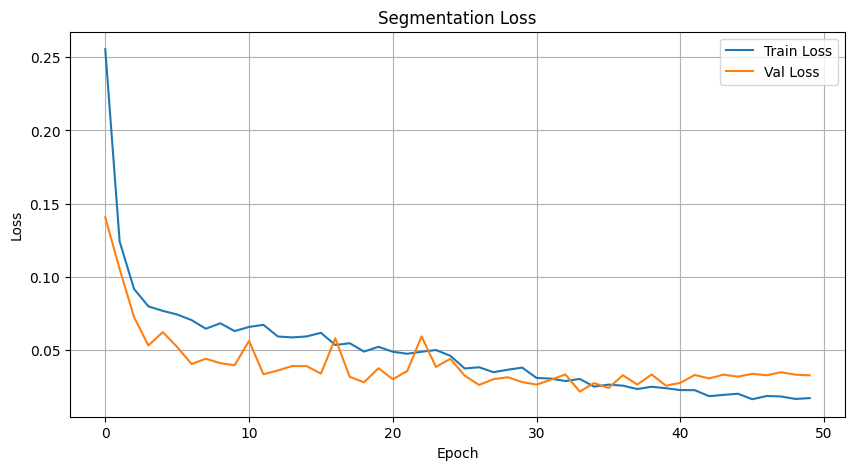

In [28]:
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(seg_history['train_loss'], label='Train Loss')
plt.plot(seg_history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Segmentation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Training Complete! 🎉

All three models have been trained:
- **Classification**: Saved as `fish_classifier.pth`
- **Localization**: Saved as `fish_localizer.pth`
- **Segmentation**: Saved as `fish_segmenter.pth`

You can now use these models for inference on new fish images!

In [30]:
# Save training histories
import pickle

with open('training_history.pkl', 'wb') as f:
    pickle.dump({
        'classification': clf_history,
        # 'localization': loc_history,
        'segmentation': seg_history
    }, f)

print("✓ Training histories saved to 'training_history.pkl'")

✓ Training histories saved to 'training_history.pkl'
